# 16.3.1 递推估计、投影与激励

## 学习目标与先修知识

按先预测后更新顺序实现标量递推辨识，展示零激励反例。

先修：6.6 递推最小二乘（recursive least squares，RLS）；16.1 反馈（feedback）。

## 具体问题

闭环控制把状态（state）压到零附近，参数（parameter）估计却可能不再变化。跟踪变好意味着清除参数已辨识吗？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型（model）对照。

In [2]:
theta=.4;P=4.;phi=1.;y=.8;gain=P*phi/(1+phi*phi*P);print("首次增益和估计：",gain,theta+gain*(y-phi*theta))

首次增益和估计： 0.8 0.7200000000000001


## 模型假设

离散回归 $y_n=a\phi_n+\epsilon_n$，$a$ 无量纲（dimensionless），$\phi,y$ 同为 U；遗忘因子（forgetting factor） $0<\lambda\le1$，初始 $P>0$，估计投影（projection）到给定区间。持续激励（persistent excitation）提供区分参数所需的信息，下面用零激励对照观察缺少信息时的更新。

## 数学解释与推导

预测误差 $e_n=y_n-\phi_n\hat a_n$，增益（gain） $g_n=P_n\phi_n/(\lambda+\phi_n^2P_n)$，先更新 $\hat a_{n+1}=\operatorname{clip}(\hat a_n+g_ne_n)$，再更新 $P_{n+1}=(P_n-g_n\phi_nP_n)/\lambda$。若所有 $\phi_n=0$，增益为零，估计不会从数据改变。投影保持声明范围，但其统计解释与未投影估计不同。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def rls_scalar(regressors,targets,theta0,p0,forget,low,high):
    theta=float(theta0);P=float(p0);estimates=[theta]
    for phi,target in zip(regressors,targets):
        gain=P*phi/(forget+phi*phi*P)
        theta=float(np.clip(theta+gain*(target-phi*theta),low,high))
        P=(P-gain*phi*P)/forget
        estimates.append(theta)
    return [estimates,float(P)]

## 对照实验

从相同初始估计出发，比较非零回归量与全零回归量；观察哪一组读数能修正参数。

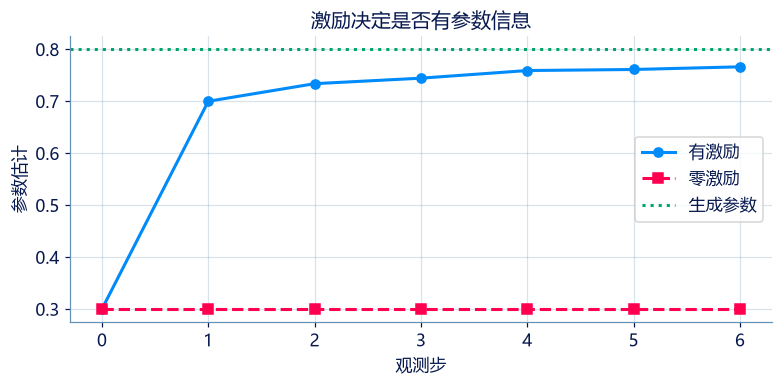

In [4]:
phi=[1.,.8,.6,.9,.4,.7];target=[.8*x for x in phi]
rich=rls_scalar(phi,target,.3,4.,1.,0.,1.)[0];weak=rls_scalar([0.]*len(phi),[0.]*len(phi),.3,4.,1.,0.,1.)[0]
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(rich,"o-",label="有激励",color=BLUE);ax.plot(weak,"s--",label="零激励",color=PINK);ax.axhline(.8,color=GREEN,ls=":",label="生成参数");ax.set(xlabel="观测步",ylabel="参数估计",title="激励决定是否有参数信息");ax.legend();ax.grid(alpha=.25);plt.show()

## 结果解释

有激励时估计接近已知参数；零回归量下估计不变。有限序列和人工无噪数据并不证明一般闭环估计无偏或一致。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
assert weak==[.3]*(len(phi)+1)
np.testing.assert_allclose(rich[-1],(.3/4+sum(x*y for x,y in zip(phi,target)))/(1/4+sum(x*x for x in phi)))
print("零激励与独立批量正则解核验通过。")

零激励与独立批量正则解核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：零回归量

若每步 φ=0，标量 RLS 的参数（parameter）估计怎样？

- **A.** 由这些观测（observation）无法改变，尽管 P 可按遗忘因子（forgetting factor）变化。
- **B.** 必收敛到真实 a。
- **C.** 每步自动加1。
- **D.** 与控制跟踪误差恒相同。

[作答：零回归量](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-zero-excitation)

### 第 2 题 · 单项选择题：递推先后

新观测（observation） y_n 到达后，哪个量先由旧估计计算？

- **A.** 下一回合的真实系数。
- **B.** 预测误差 y_n-φ_n a_hat_n。
- **C.** 未来独立评估答案。
- **D.** 只计算终点价值。

[作答：递推先后](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-rls-order)

### 第 3 题 · Python 计算题：递推估计一个系数

按给定遗忘因子（forgetting factor）和投影（projection）范围，逐个读取 φ 与 y，返回每步估计和终点 P。

**函数与代码模板**

```python
def solve(
    regressors: list[float],
    targets: list[float],
    theta0: float,
    p0: float,
    forget: float,
    low: float,
    high: float,
) -> tuple[list[float], float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `regressors` | `list[float]` | 逐步回归量。 | U |
| `targets` | `list[float]` | 相应观测（observation）。 | U |
| `theta0` | `float` | 初始系数估计。 | 1 |
| `p0` | `float` | 初始逆信息尺度。 | 1/U² |
| `forget` | `float` | 遗忘因子。 | 1 |
| `low` | `float` | 估计下界。 | 1 |
| `high` | `float` | 估计上界。 | 1 |

**返回值**

按以下顺序返回元组：(estimates, P)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `estimates` | `list[float]` | 含初始估计的路径。 | 1 |
| `P` | `float` | 更新后的逆信息尺度。 | 1/U² |

**计算规则**

每步 K=P*phi/(forget+phi²P)，先以旧估计求残差（residual），再按 theta←clip(theta+K*(target-phi*theta),low,high)，P←(P-K*phi*P)/forget。

**约束与边界**

- 回归量与观测等长，长度≤100；p0>0、0<forget≤1、low<high；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| regressors | 逐步回归量。 | [1.0] | U |
| targets | 相应观测（observation）。 | [2.0] | U |
| theta0 | 初始系数估计。 | 0 | 1 |
| p0 | 初始逆信息尺度。 | 1 | 1/U² |
| forget | 遗忘因子。 | 1 | 1 |
| low | 估计下界。 | -5 | 1 |
| high | 估计上界。 | 5 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
regressors = [1.0]
targets = [2.0]
theta0 = 0.0
p0 = 1.0
forget = 1.0
low = -5.0
high = 5.0

result = solve(regressors, targets, theta0, p0, forget, low, high)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| estimates | 含初始估计的路径。 | [0.0, 1.0] | 1 |
| P | 更新后的逆信息尺度。 | 0.5 | 1/U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 1.0], 0.5)
```

**样例解释**

首例增益（gain）为1/2，残差2，因此估计由0更新为1，P 变为1/2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：递推估计一个系数](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-rls-update)

### 第 4 题 · Python 计算题：弱激励时的递推

用相同更新规则返回零或微小回归量下的估计路径。

**函数与代码模板**

```python
def solve(
    regressors: list[float],
    targets: list[float],
    theta0: float,
    p0: float,
    forget: float,
    low: float,
    high: float,
) -> tuple[list[float], float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `regressors` | `list[float]` | 逐步回归量。 | U |
| `targets` | `list[float]` | 观测（observation）结果。 | U |
| `theta0` | `float` | 初始估计。 | 1 |
| `p0` | `float` | 初始 P。 | 1/U² |
| `forget` | `float` | 遗忘因子（forgetting factor）。 | 1 |
| `low` | `float` | 下界。 | 1 |
| `high` | `float` | 上界。 | 1 |

**返回值**

按以下顺序返回元组：(estimates, P)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `estimates` | `list[float]` | 逐步估计。 | 1 |
| `P` | `float` | 最终 P。 | 1/U² |

**计算规则**

每步 K=P*phi/(forget+phi²P)，先以旧估计求残差（residual），再按 theta←clip(theta+K*(target-phi*theta),low,high)，P←(P-K*phi*P)/forget。

**约束与边界**

- 回归量与观测等长，长度≤100；p0>0、0<forget≤1、low<high；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| regressors | 逐步回归量。 | [0.0, 0.0] | U |
| targets | 观测（observation）结果。 | [2.0, 3.0] | U |
| theta0 | 初始估计。 | 0.4 | 1 |
| p0 | 初始 P。 | 1 | 1/U² |
| forget | 遗忘因子（forgetting factor）。 | 1 | 1 |
| low | 下界。 | 0 | 1 |
| high | 上界。 | 2 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
regressors = [0.0, 0.0]
targets = [2.0, 3.0]
theta0 = 0.4
p0 = 1.0
forget = 1.0
low = 0.0
high = 2.0

result = solve(regressors, targets, theta0, p0, forget, low, high)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| estimates | 逐步估计。 | [0.4, 0.4, 0.4] | 1 |
| P | 最终 P。 | 1 | 1/U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.4, 0.4, 0.4], 1.0)
```

**样例解释**

首例每步增益（gain）都为零，估计仍是0.4；不能从观测声称已识别系数。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：弱激励时的递推](http://127.0.0.1:8000/chapters/16-03-%E9%80%92%E6%8E%A8%E8%BE%A8%E8%AF%86%E4%B8%8E%E8%87%AA%E9%80%82%E5%BA%94%E6%8E%A7%E5%88%B6/practice/?question=p16-weak-excitation)

**进一步阅读**

[Åström 与 Wittenmark 自适应控制教材的出版信息](https://books.google.com/books/about/Adaptive_Control.html?id=4CLCAgAAQBAJ)：递推估计与自适应控制的拓展入口。